In [1]:
import os
from dotenv import load_dotenv
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json

# Load environment variables
load_dotenv()

# Set seaborn style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Initialize wandb API
api = wandb.Api()

# Fetch runs from the project
entity = os.getenv("WANDB_ENTITY")
project = "intention-jailbreak-llm-sweep"

print(f"Fetching runs from {entity}/{project}...")
runs = api.runs(f"{entity}/{project}")

print(f"Found {len(runs)} runs")

Fetching runs from intention-analysis/intention-jailbreak-llm-sweep...
Found 8 runs


In [3]:
# Extract data from runs
data = []

for run in runs:
    # Parse config if it's a JSON string
    if isinstance(run.config, str):
        config = json.loads(run.config)
    else:
        config = run.config
    
    # Get model name from config - handling nested structure from sweep
    model_path = None
    if "_name_or_path" in config:
        if isinstance(config["_name_or_path"], dict):
            model_path = config["_name_or_path"].get("value")
        else:
            model_path = config["_name_or_path"]
    elif "model" in config:
        model_cfg = config["model"]
        if isinstance(model_cfg, dict):
            if "value" in model_cfg:
                model_cfg = model_cfg["value"]
            if isinstance(model_cfg, dict) and "name" in model_cfg:
                model_path = model_cfg["name"]
    
    if not model_path:
        continue
    
    # Process model name: strip provider (before /) and capitalize
    if "/" in model_path:
        model_name = model_path.split("/", 1)[1]
    else:
        model_name = model_path
    model_name = model_name.capitalize()
    
    # Fetch metrics from summary - handle both dict and string JSON
    if hasattr(run.summary, '_json_dict'):
        summary_data = run.summary._json_dict
        if isinstance(summary_data, str):
            summary_dict = json.loads(summary_data)
        else:
            summary_dict = summary_data
    else:
        summary_dict = {}
    
    row = {
        "model": model_name,
        "run_name": run.name,
        "eval/loss": summary_dict.get("eval/loss"),
        "val_semantic_sim": summary_dict.get("val_semantic_sim"),
        "val_rougeL": summary_dict.get("val_rougeL"),
        "val_rouge1": summary_dict.get("val_rouge1"),
        "val_rouge2": summary_dict.get("val_rouge2"),
        "val_bleu": summary_dict.get("val_bleu"),
    }
    
    data.append(row)

# Create DataFrame
df = pd.DataFrame(data)

print(f"Total runs extracted: {len(df)}")
print(f"\nAvailable columns: {df.columns.tolist()}")
print(f"\nNon-null counts per column:")
print(df.count())

# Remove rows with missing val_semantic_sim if it exists
if "val_semantic_sim" in df.columns:
    df = df.dropna(subset=["val_semantic_sim"])
    print(f"\nProcessed {len(df)} runs with val_semantic_sim data")
else:
    print("\nWarning: 'val_semantic_sim' not found in any runs")

df.round(3)

Total runs extracted: 8

Available columns: ['model', 'run_name', 'eval/loss', 'val_semantic_sim', 'val_rougeL', 'val_rouge1', 'val_rouge2', 'val_bleu']

Non-null counts per column:
model               8
run_name            8
eval/loss           8
val_semantic_sim    8
val_rougeL          8
val_rouge1          8
val_rouge2          8
val_bleu            8
dtype: int64

Processed 8 runs with val_semantic_sim data


,model,run_name,eval/loss,val_semantic_sim,val_rougeL,val_rouge1,val_rouge2,val_bleu
0,Qwen3-0.6b,fiery-spaceship-20,1.390,0.715,0.424,0.440,0.187,0.261
1,Qwen3-4b,fresh-salad-26,1.181,0.735,0.433,0.452,0.206,0.255
2,Qwen3-8b,wild-elevator-23,1.157,0.733,0.440,0.456,0.207,0.261
3,Gemma-3-4b-it,deft-capybara-36,1.222,0.737,0.450,0.471,0.225,0.281
4,Gemma-3-12b-it,divine-shape-43,1.130,0.742,0.457,0.473,0.225,0.272
5,Qwen3-14b,fiery-bee-43,1.145,0.741,0.447,0.466,0.223,0.267
6,Llama-3.2-1b-instruct,curious-galaxy-45,1.295,0.715,0.426,0.443,0.191,0.251
7,Llama-3.1-8b-instruct,earthy-shadow-46,1.150,0.750,0.443,0.460,0.216,0.267


In [4]:
# Create table for val_semantic_sim sorted in ascending order
df_sorted = df[["model", "val_semantic_sim"]].copy()
df_sorted["val_semantic_sim"] = df_sorted["val_semantic_sim"].round(3)
df_sorted = df_sorted.sort_values("val_semantic_sim", ascending=True).reset_index(drop=True)

print("Validation Semantic Similarity by Model (Ascending Order)")
print("=" * 60)
df_sorted

Validation Semantic Similarity by Model (Ascending Order)


,model,val_semantic_sim
0,Qwen3-0.6b,0.715
1,Llama-3.2-1b-instruct,0.715
2,Qwen3-8b,0.733
3,Qwen3-4b,0.735
4,Gemma-3-4b-it,0.737
5,Qwen3-14b,0.741
6,Gemma-3-12b-it,0.742
7,Llama-3.1-8b-instruct,0.750


Correlation Matrix:
                  eval/loss  val_semantic_sim  val_rougeL  val_rouge1  val_rouge2  val_bleu
eval/loss          1.000000         -0.877805   -0.786018   -0.769278   -0.814076 -0.337566
val_semantic_sim  -0.877805          1.000000    0.817307    0.816167    0.881867  0.593547
val_rougeL        -0.786018          0.817307    1.000000    0.990852    0.966036  0.804052
val_rouge1        -0.769278          0.816167    0.990852    1.000000    0.985277  0.825938
val_rouge2        -0.814076          0.881867    0.966036    0.985277    1.000000  0.789192
val_bleu          -0.337566          0.593547    0.804052    0.825938    0.789192  1.000000


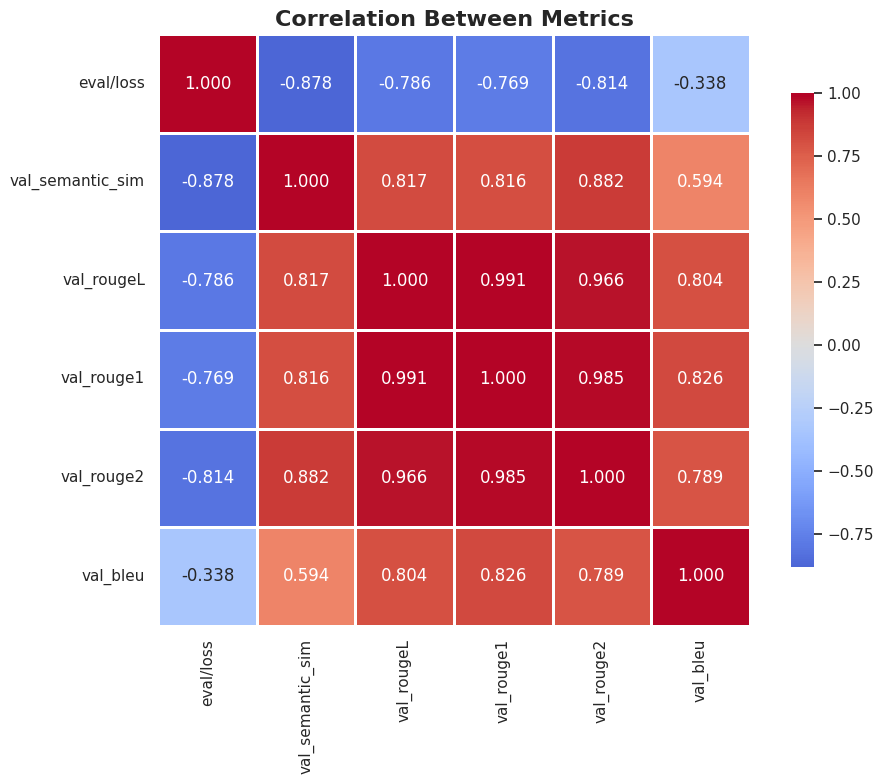

,eval/loss,val_semantic_sim,val_rougeL,val_rouge1,val_rouge2,val_bleu
eval/loss,1.000000,-0.877805,-0.786018,-0.769278,-0.814076,-0.337566
val_semantic_sim,-0.877805,1.000000,0.817307,0.816167,0.881867,0.593547
val_rougeL,-0.786018,0.817307,1.000000,0.990852,0.966036,0.804052
val_rouge1,-0.769278,0.816167,0.990852,1.000000,0.985277,0.825938
val_rouge2,-0.814076,0.881867,0.966036,0.985277,1.000000,0.789192
val_bleu,-0.337566,0.593547,0.804052,0.825938,0.789192,1.000000


In [5]:
# Calculate correlation between all metrics
metrics_cols = ["eval/loss", "val_semantic_sim", "val_rougeL", "val_rouge1", "val_rouge2", "val_bleu"]
metrics_df = df[metrics_cols].dropna()

correlation_matrix = metrics_df.corr()

print("Correlation Matrix:")
print("=" * 80)
print(correlation_matrix.to_string())
print("=" * 80)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.3f')
plt.title("Correlation Between Metrics", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

correlation_matrix